In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

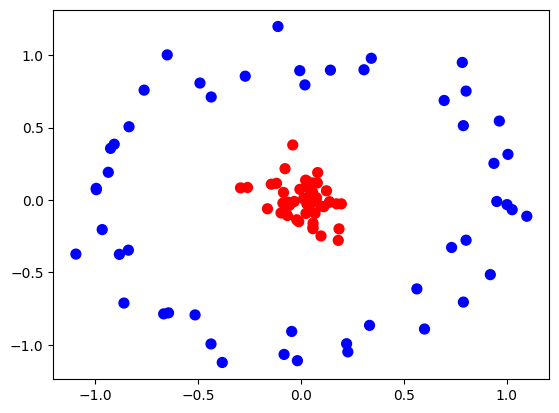

In [63]:
from sklearn.datasets import make_circles
X,y = make_circles(100, factor=.1,noise=.1)
plt.scatter(X[:,0],X[:,1],c=y,s=50,cmap='bwr')

In [64]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [65]:
svc = SVC(kernel="linear")

In [66]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [67]:
y_pred = svc.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score

In [69]:
print(accuracy_score(y_test,y_pred))

0.55


In [70]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_3772/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


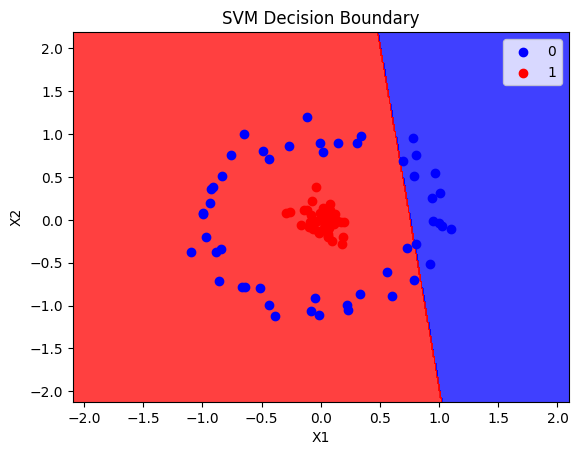

In [71]:
plot_decision_boundary(X, y, svc)

In [72]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))  ##rbf = radial basis function
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

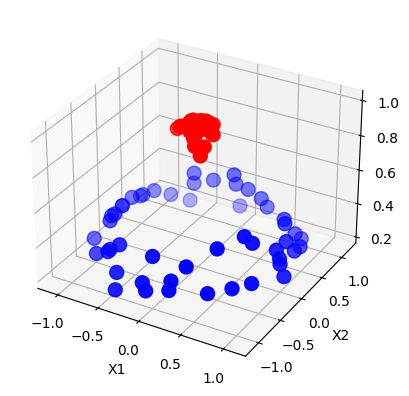

In [73]:
plot_3d_plot(X,y)

In [74]:
svc2 =SVC(kernel="rbf")
svc2.fit(X_train,y_train)

SVC()

In [75]:
y_pred2 = svc2.predict(X_test)

In [76]:
print(accuracy_score(y_test,y_pred2))

1.0


/tmp/ipykernel_3772/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


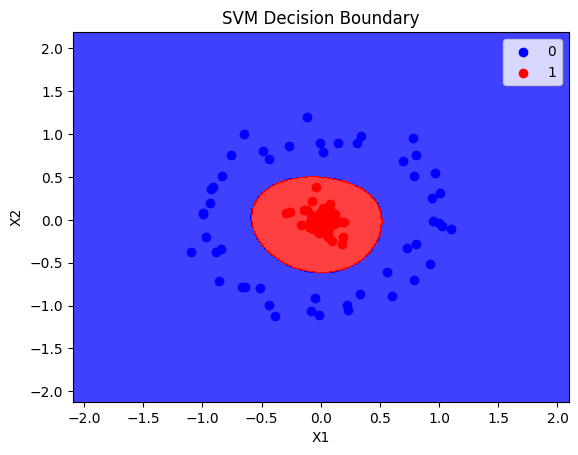

In [77]:
plot_decision_boundary(X,y,svc2)

In [78]:
##polynomial kernel degree param only works for this kernel

In [79]:
svc3 = SVC(kernel="poly")  # degree=2 performs well

In [80]:
svc3.fit(X_train,y_train)

SVC(kernel='poly')

In [81]:
y_pred3 = svc3.predict(X_test)

In [82]:
print(accuracy_score(y_test,y_pred3))

0.5


/tmp/ipykernel_3772/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


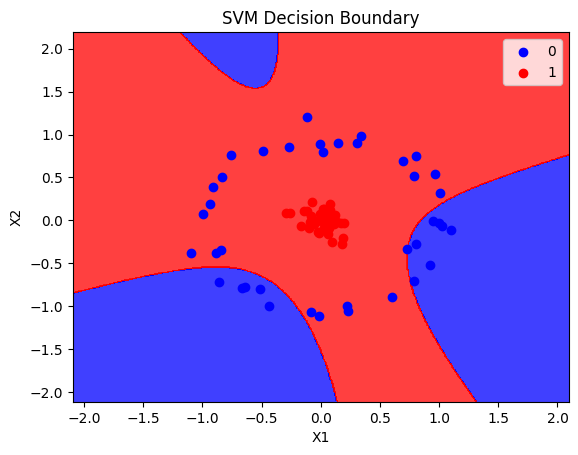

In [83]:
plot_decision_boundary(X_train,y_train,svc3)

In [86]:
X

array([[ 0.93700862,  0.25309415],
       [ 0.78850494,  0.51362848],
       [-0.02102919, -0.13628978],
       [-0.09718592, -0.08919315],
       [-0.04013856,  0.38030056],
       [ 0.09699835, -0.24806683],
       [ 0.73145763, -0.32756104],
       [-0.0332093 , -0.00988685],
       [ 0.06815666, -0.09230817],
       [ 0.69525696,  0.68744257],
       [-0.05441793, -0.03283996],
       [-1.09356177, -0.37307318],
       [ 0.78334608,  0.9499484 ],
       [-0.8355044 ,  0.50595703],
       [ 0.18085706, -0.27839561],
       [-0.11199349,  1.1982057 ],
       [ 0.95087474, -0.01002591],
       [ 0.18456811, -0.19904111],
       [-0.99470003,  0.08049373],
       [ 0.13885604, -0.01513189],
       [ 0.02681459,  0.01390785],
       [-0.64364227, -0.7789832 ],
       [ 0.05803105, -0.18703394],
       [-0.93613817,  0.19144751],
       [-0.14450516,  0.10948801],
       [-0.16305691, -0.06031077],
       [ 1.02558322, -0.06661208],
       [ 0.02867851,  0.13138674],
       [-0.49089088,

In [87]:
np.exp(-(X**2)).sum(1)

array([1.35357134, 1.30512544, 1.98115442, 1.98267551, 1.86373389,
       1.93095345, 1.4839111 , 1.99880001, 1.98688084, 1.24008758,
       1.99596519, 1.17250677, 0.94697577, 1.27169359, 1.8932431 ,
       1.22548527, 1.40478021, 1.92766545, 1.36533094, 1.98067474,
       1.99908783, 1.20590325, 1.96226115, 1.3803091 , 1.96741871,
       1.970132  , 1.34487377, 1.98206355, 1.30674077, 1.27374007,
       1.43693827, 1.36825756, 1.96162623, 1.98078656, 1.38215448,
       1.99464069, 1.99849273, 1.28302609, 1.42725806, 1.99106087,
       1.28794495, 1.328034  , 1.99858018, 1.5312793 , 1.42946198,
       1.14818964, 1.32602641, 1.97270809, 1.30060744, 1.9712435 ,
       1.99415201, 1.99002614, 1.26937588, 1.41503454, 1.94809899,
       1.15048332, 1.31442299, 1.99496574, 1.36641742, 1.30094938,
       1.92724604, 1.98571836, 1.99181376, 1.95817198, 1.98075547,
       1.99094065, 1.35613117, 1.45184911, 1.99698895, 1.14564072,
       1.02175191, 1.3669886 , 1.1381214 , 1.95830254, 1.98910

In [88]:
X_new=np.exp(-(X**2))

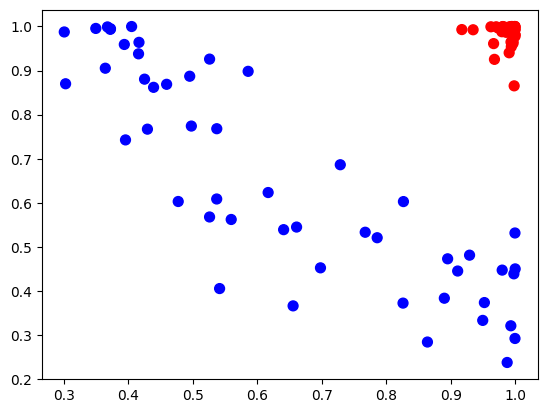

In [89]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')